In [ ]:
import os
import numpy as np
import json
from models.hybridgnet_se_resnext_dual import HybridDual
from models.hybridgnet_se_resnext import Hybrid
from models.utils import load_config
import torch
import matplotlib.pyplot as plt
import cv2
import matplotlib.gridspec as gridspec

In [ ]:
DATASET = '../Dataset/CAMUS/Landmarks_3_10'
NAME = 'CAMUS_atlas_seg'

hyperparameters = json.load(open("../Trained/CAMUS/%s/hyperparameters.json"%NAME))
config, D_t, U_t, A_t = load_config(DATASET, hyperparameters)
config['resume'] = "../Trained/CAMUS/%s/%s.pth"%(NAME, NAME)
config['raster_as_input'] = True

if config['use_dual']:
    model = HybridDual(config, D_t, U_t, A_t).to(config['device'])
else:
    model = Hybrid(config, D_t, U_t, A_t).to(config['device'])

print("Image Encoder filters", model.encoder.filters + [model.encoder.filters[-1]])
print("Bottleneck latents", model.encoder.latents)
print("Graph convolutional filters", config['filters'][::-1])

if config['resume']:
    model.load_checkpoint(config['resume'], config['device'])

model.eval()
print("Model loaded from", config['resume'])

In [ ]:
if not config["naive"]:
    organ_id = np.load("%s/NonNaive/adj_full_organ_id.npy" % DATASET)[:,0]
    organs = config['organs']
    organ_names = config['organ_names']
    organ_dict = {organs[i]: organ_names[i] for i in range(len(organ_names))}

    with open(f"{DATASET}/NonNaive/organ_order_full.json", "r") as f:
        circ_organ_order = json.load(f)
else:
    organ_id = np.load("%s/Naive/adj_full_organ_id.npy" % DATASET)[:,0]
    organs = config['organs']
    organ_names = config['organ_names']
    organ_dict = {organs[i]: organ_names[i] for i in range(len(organ_names))}
    
# Define colors for visualization
organ_colors = {
    'LV Endo': 'red',
    'LV Epi': 'green', 
    'LA': 'blue'
}


In [ ]:
import pandas as pd 
from medpy.metric.binary import dc as dice_score
from medpy.metric.binary import hd, assd

images_path = "/home/ngaggion/Documents/Mask2Graph/CAMUS/nnUNet_raw/predTs"
images = sorted([f for f in os.listdir(images_path) if f.endswith('.png')])
images = [os.path.join(images_path, f) for f in images]

df = pd.DataFrame(columns=['Image', 'Organ', 'Dice', 'Unified'])

for i, image_path in enumerate(images):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    # scale is pad to square then resize to 512x512
    # padding to square
    h, w = image.shape
    if h > w:
        pad = (h - w) // 2
        image = cv2.copyMakeBorder(image, 0, 0, pad, pad, cv2.BORDER_CONSTANT, value=0)
    elif w > h:
        pad = (w - h) // 2
        image = cv2.copyMakeBorder(image, pad, pad, 0, 0, cv2.BORDER_CONSTANT, value=0)
    image = cv2.resize(image, (512, 512))
    
    one_hot = np.zeros((3, 512, 512), dtype=np.float32)
    one_hot[0, :, :] = (image == 1).astype(np.float32)
    one_hot[0, :, :] = cv2.morphologyEx(one_hot[0, :, :], cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
    
    contours, _ = cv2.findContours((one_hot[0, :, :] * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        blank = np.zeros((512, 512), dtype=np.float32)
        cv2.drawContours(blank, [largest_contour], -1, 1, thickness=cv2.FILLED)
        one_hot[0, :, :] = blank
        
    one_hot[1, :, :] = (image == 2).astype(np.float32)
    one_hot[1, :, :] = cv2.morphologyEx(one_hot[1, :, :], cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
    
    contours, _ = cv2.findContours((one_hot[1, :, :] * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        blank = np.zeros((512, 512), dtype=np.float32)
        cv2.drawContours(blank, [largest_contour], -1, 1, thickness=cv2.FILLED)
        one_hot[1, :, :] = blank
        
    one_hot[2, :, :] = (image == 3).astype(np.float32)
    one_hot[2, :, :] = cv2.morphologyEx(one_hot[2, :, :], cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
    
    contours, _ = cv2.findContours((one_hot[2, :, :] * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        blank = np.zeros((512, 512), dtype=np.float32)
        cv2.drawContours(blank, [largest_contour], -1, 1, thickness=cv2.FILLED)
        one_hot[2, :, :] = blank
    
    image = one_hot
    image = (image - image.min()) / (image.max() - image.min())
    
    input = torch.tensor(image, dtype=torch.float32).to(config['device'])
    input = input.unsqueeze(0)  # Add batch dimension
    output = model(input)[0]
    
    for organ in organs:
        # Get indices for this organ
        if config["naive"]:
            idx_organ = organ_id == int(organ)
        else:            
            idx_organ = circ_organ_order[organ]
    
        organ_name = organ_dict[str(int(organ))]
        pred_organ = output[0, idx_organ].cpu().detach().numpy() * 512

        # fill the contour 
        blank = np.zeros((512, 512), dtype=np.float32)
        cv2.drawContours(blank, [pred_organ.astype(np.int32)], -1, 1, thickness=cv2.FILLED)
        
        dice = dice_score(blank, one_hot[int(organ)-1, :, :])
        hausdorf = hd(blank, one_hot[int(organ)-1, :, :])
        assd_val = assd(blank, one_hot[int(organ)-1, :, :])
        aux = pd.DataFrame({'Image': [image_path], 'Organ': [organ_name], 'Dice': [dice], 'HD': [hausdorf], 'ASSD': [assd_val], 'Unified': [not config['naive']]}).reset_index(drop=True)
        df = pd.concat([df, aux], ignore_index=True)



In [ ]:
DATASET = '../Dataset/CAMUS/Landmarks_3_10'
NAME = 'CAMUS_atlas_seg_NN'

hyperparameters = json.load(open("../Trained/CAMUS/%s/hyperparameters.json"%NAME))
config, D_t, U_t, A_t = load_config(DATASET, hyperparameters)
config['resume'] = "../Trained/CAMUS/%s/%s.pth"%(NAME, NAME)
config['raster_as_input'] = True

if config['use_dual']:
    model = HybridDual(config, D_t, U_t, A_t).to(config['device'])
else:
    model = Hybrid(config, D_t, U_t, A_t).to(config['device'])

print("Image Encoder filters", model.encoder.filters + [model.encoder.filters[-1]])
print("Bottleneck latents", model.encoder.latents)
print("Graph convolutional filters", config['filters'][::-1])

if config['resume']:
    model.load_checkpoint(config['resume'], config['device'])

model.eval()
print("Model loaded from", config['resume'])

In [ ]:
if not config["naive"]:
    organ_id = np.load("%s/NonNaive/adj_full_organ_id.npy" % DATASET)[:,0]
    organs = config['organs']
    organ_names = config['organ_names']
    organ_dict = {organs[i]: organ_names[i] for i in range(len(organ_names))}

    with open(f"{DATASET}/NonNaive/organ_order_full.json", "r") as f:
        circ_organ_order = json.load(f)
else:
    organ_id = np.load("%s/Naive/adj_full_organ_id.npy" % DATASET)[:,0]
    organs = config['organs']
    organ_names = config['organ_names']
    organ_dict = {organs[i]: organ_names[i] for i in range(len(organ_names))}
    
# Define colors for visualization
organ_colors = {
    'LV Endo': 'red',
    'LV Epi': 'green', 
    'LA': 'blue'
}


In [ ]:
import pandas as pd 
from medpy.metric.binary import dc as dice_score
from medpy.metric.binary import hd, assd

images_path = "/home/ngaggion/Documents/Mask2Graph/CAMUS/nnUNet_raw/predTs"
images = sorted([f for f in os.listdir(images_path) if f.endswith('.png')])
images = [os.path.join(images_path, f) for f in images]

df2 = pd.DataFrame(columns=['Image', 'Organ', 'Dice', 'Unified'])

for i, image_path in enumerate(images):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    # scale is pad to square then resize to 512x512
    # padding to square
    h, w = image.shape
    if h > w:
        pad = (h - w) // 2
        image = cv2.copyMakeBorder(image, 0, 0, pad, pad, cv2.BORDER_CONSTANT, value=0)
    elif w > h:
        pad = (w - h) // 2
        image = cv2.copyMakeBorder(image, pad, pad, 0, 0, cv2.BORDER_CONSTANT, value=0)
    image = cv2.resize(image, (512, 512))
    
    one_hot = np.zeros((3, 512, 512), dtype=np.float32)
    one_hot[0, :, :] = (image == 1).astype(np.float32)
    one_hot[0, :, :] = cv2.morphologyEx(one_hot[0, :, :], cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
    
    contours, _ = cv2.findContours((one_hot[0, :, :] * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        blank = np.zeros((512, 512), dtype=np.float32)
        cv2.drawContours(blank, [largest_contour], -1, 1, thickness=cv2.FILLED)
        one_hot[0, :, :] = blank
        
    one_hot[1, :, :] = (image == 2).astype(np.float32)
    one_hot[1, :, :] = cv2.morphologyEx(one_hot[1, :, :], cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
    
    contours, _ = cv2.findContours((one_hot[1, :, :] * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        blank = np.zeros((512, 512), dtype=np.float32)
        cv2.drawContours(blank, [largest_contour], -1, 1, thickness=cv2.FILLED)
        one_hot[1, :, :] = blank
        
    one_hot[2, :, :] = (image == 3).astype(np.float32)
    one_hot[2, :, :] = cv2.morphologyEx(one_hot[2, :, :], cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
    
    contours, _ = cv2.findContours((one_hot[2, :, :] * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        blank = np.zeros((512, 512), dtype=np.float32)
        cv2.drawContours(blank, [largest_contour], -1, 1, thickness=cv2.FILLED)
        one_hot[2, :, :] = blank
    
    image = one_hot
    image = (image - image.min()) / (image.max() - image.min())
    
    input = torch.tensor(image, dtype=torch.float32).to(config['device'])
    input = input.unsqueeze(0)  # Add batch dimension
    output = model(input)[0]
    
    for organ in organs:
        # Get indices for this organ
        if config["naive"]:
            idx_organ = organ_id == int(organ)
        else:            
            idx_organ = circ_organ_order[organ]
    
        organ_name = organ_dict[str(int(organ))]
        pred_organ = output[0, idx_organ].cpu().detach().numpy() * 512

        # fill the contour 
        blank = np.zeros((512, 512), dtype=np.float32)
        cv2.drawContours(blank, [pred_organ.astype(np.int32)], -1, 1, thickness=cv2.FILLED)
        
        dice = dice_score(blank, one_hot[int(organ)-1, :, :])
        hausdorf = hd(blank, one_hot[int(organ)-1, :, :])
        assd_val = assd(blank, one_hot[int(organ)-1, :, :])
        aux = pd.DataFrame({'Image': [image_path], 'Organ': [organ_name], 'Dice': [dice], 'HD': [hausdorf], 'ASSD': [assd_val], 'Unified': [not config['naive']]}).reset_index(drop=True)
        df2 = pd.concat([df2, aux], ignore_index=True)



In [ ]:
# concat df and df2
df_3 = pd.concat([df, df2], ignore_index=True)

# store
df_3.to_csv("/home/ngaggion/Documents/Mask2Graph/Results/CAMUS/atlas_seg.csv")

In [ ]:
import pandas as pd

# 1. Process nnUNet-based results (df_3)
# Assuming df_3 has columns: 'Dice', 'hd', 'assd'
summary = df_3.groupby(['Organ', 'Unified']).agg({
    'Dice': ['mean', 'std'],
    'HD': ['mean', 'std'],
    'ASSD': ['mean', 'std']
}).reset_index()

# Flatten columns: ['Organ', 'Unified', 'Mean Dice', 'Std Dice', 'Mean HD', 'Std HD', ...]
summary.columns = ['Organ', 'Unified', 'Mean Dice', 'Std Dice', 'Mean HD', 'Std HD', 'Mean ASSD', 'Std ASSD']
summary['Unified'] = summary['Unified'].apply(lambda x: 'Unified' if x else 'Independent')

# 2. Load and Process GT-based results
df_gt_non_naive = pd.read_csv("../Results/CAMUS/CAMUS_atlas_seg_NN/results.csv")
df_gt_non_naive['Unified'] = True
df_gt_naive = pd.read_csv("../Results/CAMUS/CAMUS_atlas_seg/results.csv")
df_gt_naive['Unified'] = False
df_gt = pd.concat([df_gt_non_naive, df_gt_naive], ignore_index=True)
df_gt.rename(columns={'organ': 'Organ'}, inplace=True)

# Assuming df_gt uses 'dc', 'hd', 'assd'
summary_gt = df_gt.groupby(['Organ', 'Unified']).agg({
    'dc': ['mean', 'std'],
    'hd': ['mean', 'std'],
    'assd': ['mean', 'std']
}).reset_index()

summary_gt.columns = ['Organ', 'Unified', 'Mean Dice', 'Std Dice', 'Mean HD', 'Std HD', 'Mean ASSD', 'Std ASSD']
summary_gt['Unified'] = summary_gt['Unified'].apply(lambda x: 'Unified' if x else 'Independent')

# 3. Final Formatting (Round and Create Strings)
for df in [summary, summary_gt]:
    for metric in ['Dice', 'HD', 'ASSD']:
        df[f'{metric}_Score'] = df[f'Mean {metric}'].round(3).astype(str) + ' ± ' + df[f'Std {metric}'].round(3).astype(str)

# 4. Merge for the Side-by-Side Comparison
summary['Source'] = 'nnUNet'
summary_gt['Source'] = 'GT'

combined = pd.concat([
    summary[['Organ', 'Unified', 'Source', 'Dice_Score', 'HD_Score', 'ASSD_Score']],
    summary_gt[['Organ', 'Unified', 'Source', 'Dice_Score', 'HD_Score', 'ASSD_Score']]
])

TypeError: agg function failed [how->mean,dtype->object]

In [58]:
# 1. Assuming you already have the 'combined' dataframe from the previous step
# Order the metrics for the table
metric_order = ['Dice_Score', 'HD_Score', 'ASSD_Score']
source_order = ['GT', 'nnUNet']

# 2. Pivot the data
# We use the categorical Source/Organ to ensure the order is correct
combined['Source'] = pd.Categorical(combined['Source'], categories=source_order)
combined['Organ'] = pd.Categorical(combined['Organ'], categories=['LA', 'LV Endo', 'LV Epi'])

pivot_table = combined.pivot_table(
    index=['Organ', 'Unified'], 
    columns='Source', 
    values=metric_order,
    aggfunc='first'
)

# 3. Generate the LaTeX Code String
latex_str = r"""
\begin{table*}[t!]
\centering
\resizebox{\linewidth}{!}{
\begin{tabular}{ll ccc ccc ccc}
\toprule
& & \multicolumn{2}{c}{\textbf{Dice Coefficient $\uparrow$}} & \multicolumn{2}{c}{\textbf{HD (pixels) $\downarrow$}} & \multicolumn{2}{c}{\textbf{ASSD (pixels) $\downarrow$}} \\
\cmidrule(lr){3-4} \cmidrule(lr){5-6} \cmidrule(lr){7-8}
\textbf{Organ} & \textbf{Graph Type} & \textbf{GT Input} & \textbf{nnUNet Input} & \textbf{GT Input} & \textbf{nnUNet Input} & \textbf{GT Input} & \textbf{nnUNet Input} \\
\midrule
"""

# 4. Fill in the data rows dynamically
for organ in ['LA', 'LV Endo', 'LV Epi']:
    for unified in ['Independent', 'Unified']:
        # Extract values for the specific row
        dice_gt = pivot_table.loc[(organ, unified), ('Dice_Score', 'GT')]
        dice_nn = pivot_table.loc[(organ, unified), ('Dice_Score', 'nnUNet')]
        hd_gt = pivot_table.loc[(organ, unified), ('HD_Score', 'GT')]
        hd_nn = pivot_table.loc[(organ, unified), ('HD_Score', 'nnUNet')]
        assd_gt = pivot_table.loc[(organ, unified), ('ASSD_Score', 'GT')]
        assd_nn = pivot_table.loc[(organ, unified), ('ASSD_Score', 'nnUNet')]
        
        row_str = f"{organ} & {unified} & {dice_gt} & {dice_nn} & {hd_gt} & {hd_nn} & {assd_gt} & {assd_nn} \\\\\n"
        
        # Add a midrule after the second row of each organ (except the last one)
        if unified == 'Unified' and organ != 'LV Epi':
            row_str += "\\midrule\n"
            
        latex_str += row_str

latex_str += r"""\bottomrule
\end{tabular}}
\end{table*}
"""

print(latex_str)


\begin{table*}[t!]
\centering
\resizebox{\linewidth}{!}{
\begin{tabular}{ll ccc ccc ccc}
\toprule
& & \multicolumn{2}{c}{\textbf{Dice Coefficient $\uparrow$}} & \multicolumn{2}{c}{\textbf{HD (pixels) $\downarrow$}} & \multicolumn{2}{c}{\textbf{ASSD (pixels) $\downarrow$}} \\
\cmidrule(lr){3-4} \cmidrule(lr){5-6} \cmidrule(lr){7-8}
\textbf{Organ} & \textbf{Graph Type} & \textbf{GT Input} & \textbf{nnUNet Input} & \textbf{GT Input} & \textbf{nnUNet Input} & \textbf{GT Input} & \textbf{nnUNet Input} \\
\midrule
LA & Independent & 0.988 ± 0.005 & 0.986 ± 0.004 & 3.06 ± 1.425 & 2.834 ± 1.216 & 0.709 ± 0.204 & 0.746 ± 0.131 \\
LA & Unified & 0.99 ± 0.004 & 0.989 ± 0.003 & 2.852 ± 1.053 & 2.532 ± 0.707 & 0.613 ± 0.183 & 0.595 ± 0.084 \\
\midrule
LV Endo & Independent & 0.99 ± 0.002 & 0.989 ± 0.002 & 3.096 ± 0.978 & 2.774 ± 0.694 & 0.769 ± 0.133 & 0.748 ± 0.087 \\
LV Endo & Unified & 0.991 ± 0.002 & 0.99 ± 0.002 & 6.224 ± 3.407 & 4.472 ± 1.866 & 0.7 ± 0.102 & 0.683 ± 0.063 \\
\midrule
LV Epi 

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch
import random

# --- Configuration ---
# User Request: Only Squares
marker_style = 's' 

# Organ Colors (Red, Green, Blue)
organ_colors = {
    '1': 'red',    # LV Endo
    '2': 'green',  # LV Epi
    '3': 'blue'    # Left Atrium
}

# Containers
all_pred_contours = {org: [] for org in organs}
example_data = [] 

print("Collecting predictions...")
with torch.no_grad():
    for i, image_path in enumerate(images):
        # --- Preprocessing ---
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        h, w = image.shape
        if h > w:
            pad = (h - w) // 2
            image = cv2.copyMakeBorder(image, 0, 0, pad, pad, cv2.BORDER_CONSTANT, value=0)
        elif w > h:
            pad = (w - h) // 2
            image = cv2.copyMakeBorder(image, pad, pad, 0, 0, cv2.BORDER_CONSTANT, value=0)
        image = cv2.resize(image, (512, 512))
        
        # Create One-Hot
        one_hot = np.zeros((3, 512, 512), dtype=np.float32)
        one_hot[0, :, :] = (image == 1).astype(np.float32)
        one_hot[1, :, :] = (image == 2).astype(np.float32)
        one_hot[2, :, :] = (image == 3).astype(np.float32)
        one_hot[0, :, :] = cv2.morphologyEx(one_hot[0, :, :], cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
        one_hot[1, :, :] = cv2.morphologyEx(one_hot[1, :, :], cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
        one_hot[2, :, :] = cv2.morphologyEx(one_hot[2, :, :], cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
        
        # Inference
        input_tensor = (one_hot - one_hot.min()) / (one_hot.max() - one_hot.min())
        input = torch.tensor(input_tensor, dtype=torch.float32).to(config['device']).unsqueeze(0)
        output = model(input)[0]
        
        subject_contours = {}
        for organ in organs:
            if config["naive"]:
                idx_organ = organ_id == int(organ)
            else:            
                idx_organ = circ_organ_order[organ]
            
            # Get coords (N, 2)
            pred_organ = output[0, idx_organ].cpu().detach().numpy() * 512
            all_pred_contours[organ].append(pred_organ)
            subject_contours[organ] = pred_organ
        
        # Save 3 specific examples
        if len(example_data) < 3 and i in [3, 12, 37]: 
            # Visualization Mask
            vis_img = np.zeros((512, 512))
            vis_img += one_hot[0] * 1 
            vis_img += one_hot[1] * 2
            vis_img += one_hot[2] * 3
            example_data.append((vis_img, subject_contours))

# --- Compute Mean Atlas ---
mean_contours = {}
for organ in organs:
    mean_contours[organ] = np.mean(np.array(all_pred_contours[organ]), axis=0)

In [41]:
print("2. Optimizing marker locations to avoid overlaps...")

# Initial Selection: 5 equidistant nodes per organ
selected_indices = {}
for organ in organs:
    num_nodes = len(mean_contours[organ])
    # Start with standard linspace
    idxs = np.linspace(0, num_nodes-1, 8, dtype=int)[:-1]
    selected_indices[organ] = list(idxs)

# Comparison Loop
# We check every marker against every marker from other organs.
# If they are too close, we shift the *second* marker's index by 1 and retry.
organs_list = list(organs)

# Run a few passes to resolve cascading collisions
for _ in range(3): 
    for i in range(len(organs_list)):
        org_A = organs_list[i]
        coords_A = mean_contours[org_A]
        
        for j in range(i + 1, len(organs_list)):
            org_B = organs_list[j]
            coords_B = mean_contours[org_B]
            
            # Compare every selected node in A vs every selected node in B
            for idx_a_ptr in range(len(selected_indices[org_A])):
                idx_A = selected_indices[org_A][idx_a_ptr]
                pos_A = coords_A[idx_A]
                
                for idx_b_ptr in range(len(selected_indices[org_B])):
                    idx_B = selected_indices[org_B][idx_b_ptr]
                    pos_B = coords_B[idx_B]
                    
                    # Calculate Distance
                    dist = np.linalg.norm(pos_A - pos_B)
                    
                    # COLLISION RESOLUTION
                    while dist < 30:
                        # Shift Index B forward
                        idx_B = (idx_B + 1) % len(coords_B)
                        
                        # Update position and distance
                        pos_B = coords_B[idx_B]
                        dist = np.linalg.norm(pos_A - pos_B)
                    
                    # Save the new valid index
                    selected_indices[org_B][idx_b_ptr] = idx_B

2. Optimizing marker locations to avoid overlaps...


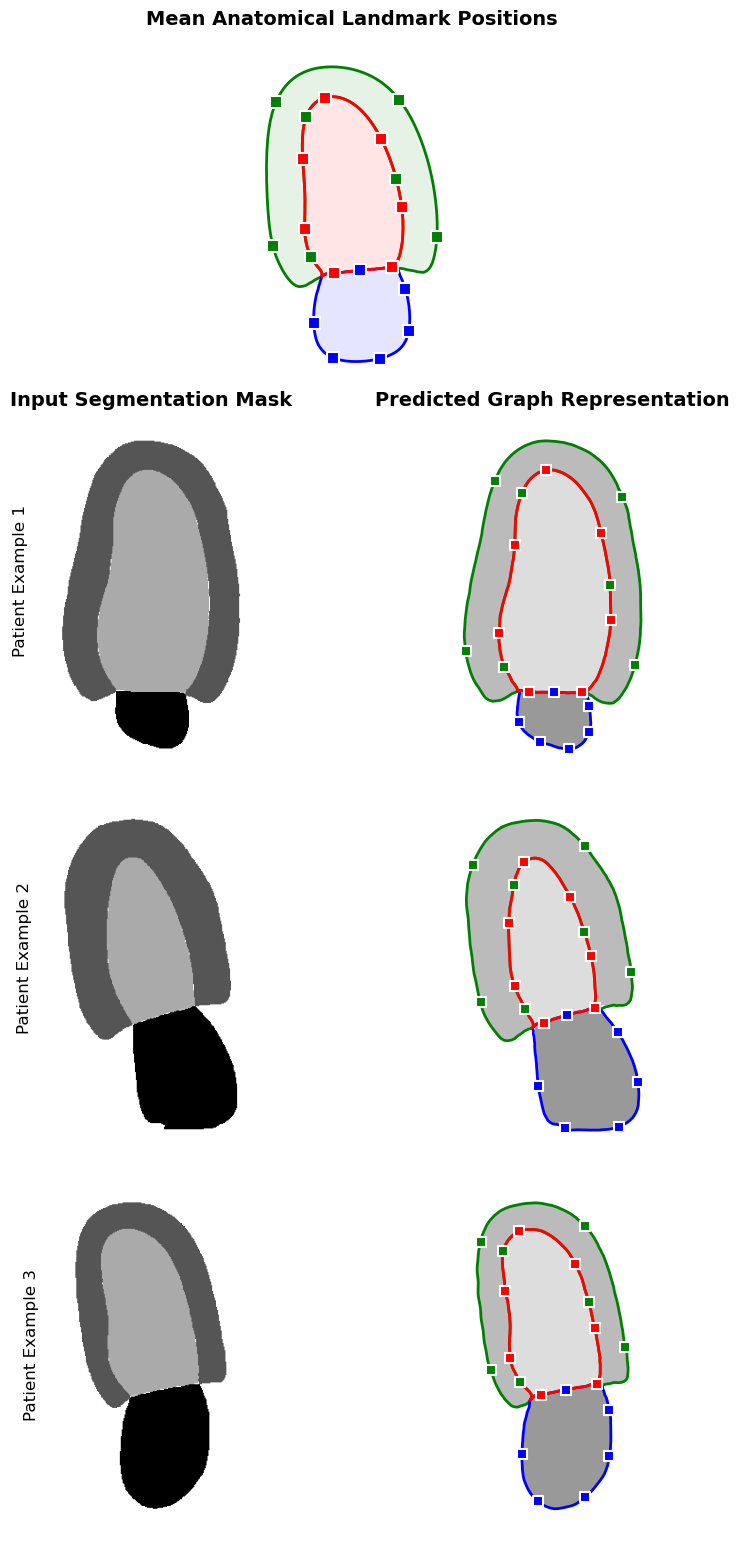

In [57]:
# --- Helper: Calculate Auto-Crop for a specific set of contours ---
def get_crop_bounds(contours_dict, padding=30):
    all_points = []
    for organ in contours_dict:
        all_points.append(contours_dict[organ])
    
    # Stack all points to find the bounding box for this specific subject
    stack = np.vstack(all_points)
    min_x, min_y = np.min(stack, axis=0)
    max_x, max_y = np.max(stack, axis=0)
    
    # Return limits with padding (Y inverted for Images later)
    # X: (Left, Right), Y: (Bottom, Top) -> Matplotlib inverts Y for images
    return (min_x - padding, max_x + padding), (max_y + padding, min_y - padding)

# --- Plotting ---
# Define draw order for layering: Epi (2) -> LA (3) -> Endo (1)
draw_order = ['2', '3', '1']

fig = plt.figure(figsize=(8, 16)) 
# Minimize layout whitespace
plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.01, right=0.99, top=0.95, bottom=0.01)

# --- Row 1: Mean Atlas ---
ax_mean = plt.subplot2grid((4, 2), (0, 0), colspan=2)
ax_mean.set_title("Mean Anatomical Landmark Positions", fontsize=14, fontweight='bold')

# Calculate Bounds just for Mean Atlas
lim_x, lim_y = get_crop_bounds(mean_contours, padding=40)
ax_mean.set_xlim(*lim_x); ax_mean.set_ylim(*lim_y)
ax_mean.set_aspect('equal')
ax_mean.axis('off')

for organ in draw_order:
    if organ not in mean_contours: continue
    color = organ_colors[organ]
    coords = mean_contours[organ]
    closed_coords = np.vstack([coords, coords[0]])
    
    # Continuous Line + Faint Fill
    ax_mean.plot(closed_coords[:, 0], closed_coords[:, 1], c=color, linewidth=2, zorder=10)
    ax_mean.fill(closed_coords[:, 0], closed_coords[:, 1], color=color, alpha=0.1, zorder=5)
    
    # Optimized Markers
    for idx in selected_indices[organ]:
        ax_mean.scatter(coords[idx, 0], coords[idx, 1], 
                        c=color, marker=marker_style, s=80, 
                        edgecolors='white', linewidth=1.5, zorder=20)

# --- Rows 2-4: Patient Examples ---
for j, (img, contours) in enumerate(example_data):
    row_idx = j + 1
    
    # Calculate specific crop for THIS patient
    lim_x, lim_y = get_crop_bounds(contours, padding=30)
    
    # --- Left: Mask ---
    ax_mask = plt.subplot2grid((4, 2), (row_idx, 0))
    ax_mask.imshow(img, cmap='gray_r')
    ax_mask.set_xlim(*lim_x); ax_mask.set_ylim(*lim_y) # Apply Individual Crop
    ax_mask.axis('off')
    
    # Label inside box (using data coordinates)
    # Write patient number at the left, rotaded 90 degrees
    ax_mask.text(lim_x[0] - 25, lim_y[1] + 100, f"Patient Example {j+1}", 
                 fontsize=12, color='black',
                 rotation=90, verticalalignment='top', horizontalalignment='left',
                 )

    if j == 0:
        ax_mask.set_title("Input Segmentation Mask", fontsize=14, fontweight='bold')
        
    # --- Right: Graph ---
    ax_graph = plt.subplot2grid((4, 2), (row_idx, 1))
    ax_graph.imshow(img, cmap='gray_r', alpha=0.4) 
    
    if j == 0:
        ax_graph.set_title("Predicted Graph Representation", fontsize=14, fontweight='bold')
    
    for organ in draw_order:
        if organ not in contours: continue
        color = organ_colors[organ]
        coords = contours[organ]
        closed_coords = np.vstack([coords, coords[0]])
        
        ax_graph.plot(closed_coords[:, 0], closed_coords[:, 1], c=color, linewidth=2, zorder=10)
        
        # Markers
        for idx in selected_indices[organ]:
            ax_graph.scatter(coords[idx, 0], coords[idx, 1], 
                             c=color, marker=marker_style, s=60, 
                             edgecolors='white', linewidth=1.5, zorder=20)
    
    ax_graph.set_xlim(*lim_x); ax_graph.set_ylim(*lim_y) # Apply Individual Crop
    ax_graph.axis('off')

plt.savefig("correspondence_visual_final.svg", dpi=300, bbox_inches='tight', pad_inches=0.02)
plt.show()